<a href="https://colab.research.google.com/github/leninworld/lights_forest_fire_mapping_2024/blob/main/Forest_Fire_Analysis_Dataset_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#California Wildfires Dataset (Dataset I)

##Schema of Dataset
#####AcresBurned - Acres of land affected by wildfires
#####Active - If the fire is active or contained?
#####ArchiveYear - Year the incident took place
#####CalFireIncident - Is the incident treated as a CalFire incident?
#####Counties - County name
#####CountyIds - County id
#####Latitude - Latitude of the Wildfire incident
####Location - Description of the location
#####Longitude - Longitude of the Wildfire incident
#####Name - Name of the fire incident
#####Status - Status of fire finalized or inactive



###Reading California forest fire dataset from drive.

In [1]:
from google.colab import drive
# NOTE: this will pop up asking for google login permission1
drive.mount('/content/drive')
# linux command to list the files under linux running
#Colab Jupyter notebook (prints dir/files/links in your Drive)
!ls -ltr /content/drive/MyDrive/ | grep *.csv

Mounted at /content/drive
ls: '/content/drive/MyDrive/dataset (1)': No such file or directory
ls: /content/drive/MyDrive/dataset_csv: No such file or directory
ls: /content/drive/MyDrive/dataset: No such file or directory
ls: /content/drive/MyDrive/Dataset-2024-Food-Production-SRM: No such file or directory


In [2]:
!ls -ltr /content/drive/MyDrive/surya_data/California_Fire_Incidents_V1.csv

-rw------- 1 root root 203166 Jan  5  2023 /content/drive/MyDrive/surya_data/California_Fire_Incidents_V1.csv


In [3]:
import csv
import re
import random
import traceback
from tabulate import tabulate
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import xlrd
import glob
import numpy as np
import datetime
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.neural_network import MLPClassifier,MLPRegressor
from sklearn.tree import DecisionTreeRegressor as dtr
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import r2_score
from sklearn import svm
from sklearn import metrics
from sklearn import preprocessing
from sklearn import linear_model
from scipy import stats
import warnings
warnings.filterwarnings(action='ignore')
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.neural_network import MLPClassifier

In [4]:
def pretty_print(df, n):
  print(tabulate(df.head(n),headers='keys',tablefmt='psql'))

In [5]:
df_california=pd.read_csv('/content/drive/MyDrive/surya_data/California_Fire_Incidents_V1.csv')
pretty_print(df_california,1)
print('Shape', df_california.shape)

+----+---------------+----------+---------------+-------------------+------------+-------------+------------+-----------------------------------------+-------------+----------+-----------+
|    |   AcresBurned | Active   |   ArchiveYear | CalFireIncident   | Counties   |   CountyIds |   Latitude | Location                                |   Longitude | Name     | Status    |
|----+---------------+----------+---------------+-------------------+------------+-------------+------------+-----------------------------------------+-------------+----------+-----------|
|  0 |        257314 | False    |          2013 | True              | Tuolumne   |          55 |     37.857 | 3 miles east of Groveland along Hwy 120 |    -120.086 | Rim Fire | Finalized |
+----+---------------+----------+---------------+-------------------+------------+-------------+------------+-----------------------------------------+-------------+----------+-----------+
Shape (1636, 11)


###Dtypes

In [6]:
df_california.info()
df_california.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1636 entries, 0 to 1635
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   AcresBurned      1633 non-null   float64
 1   Active           1636 non-null   bool   
 2   ArchiveYear      1636 non-null   int64  
 3   CalFireIncident  1636 non-null   bool   
 4   Counties         1636 non-null   object 
 5   CountyIds        1636 non-null   object 
 6   Latitude         1636 non-null   float64
 7   Location         1636 non-null   object 
 8   Longitude        1636 non-null   float64
 9   Name             1636 non-null   object 
 10  Status           1636 non-null   object 
dtypes: bool(2), float64(3), int64(1), object(5)
memory usage: 118.4+ KB


AcresBurned        float64
Active                bool
ArchiveYear          int64
CalFireIncident       bool
Counties            object
CountyIds           object
Latitude           float64
Location            object
Longitude          float64
Name                object
Status              object
dtype: object

###Data Statistics

In [7]:
df_california.describe().T

,count,mean,std,min,25%,50%,75%,max
AcresBurned,1633.0,4589.443968,27266.337722,0.00000,35.000000,100.000000,422.000000,410203.0000
ArchiveYear,1636.0,2016.608802,1.845340,2013.00000,2015.000000,2017.000000,2018.000000,2019.0000
Latitude,1636.0,37.203975,135.401380,-120.25800,34.165891,37.104065,39.086808,5487.0000
Longitude,1636.0,-108.082642,37.006927,-124.19629,-121.768358,-120.461560,-117.474073,118.9082


#

In [8]:
df_pca = df_california.copy()
df_pca['AcresBurned'] = df_pca['AcresBurned'].fillna(0)
print(df_pca)

      AcresBurned  Active  ArchiveYear  CalFireIncident     Counties  \
0        257314.0   False         2013             True     Tuolumne   
1         30274.0   False         2013             True  Los Angeles   
2         27531.0   False         2013             True    Riverside   
3         27440.0   False         2013            False       Placer   
4         24251.0   False         2013             True      Ventura   
...           ...     ...          ...              ...          ...   
1631          9.0   False         2019             True    Riverside   
1632          2.0   False         2019             True       Nevada   
1633          0.0   False         2019            False         Yolo   
1634          0.0   False         2019            False    San Diego   
1635          0.0   False         2019            False    Riverside   

     CountyIds   Latitude                                           Location  \
0           55  37.857000            3 miles east of Gr

<Figure size 1000x600 with 0 Axes>

<Axes: >

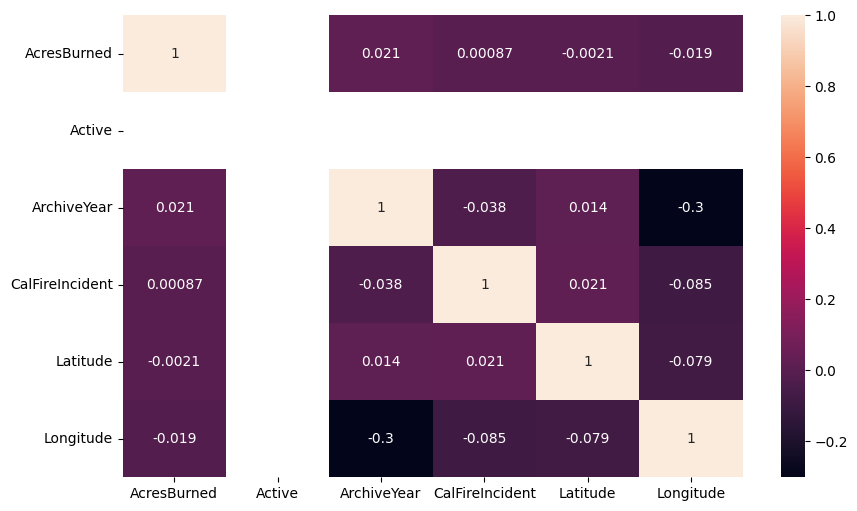

In [9]:
# Corelation Coefficient
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

#corelation matrix
correlation = df_pca.corr()

#plotting heatmap
plt.figure(figsize = (10,6))
sns.heatmap(correlation, annot = True)

In [10]:
!pip install skfeature-chappers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.3/66.3 kB 2.0 MB/s eta 0:00:00


#### Ordinal Encoding On Categorical Varibles for PCA.

In [11]:
# Ordinal encoding on multiple columns conversion of categorical to numeric values without labels
enc = OrdinalEncoder()
enc.fit(df_pca[["Active", "Name", "Status", "Location", "CalFireIncident", "Counties", "CountyIds"]])
df_pca[["Active", "Name", "Status", "Location", "CalFireIncident", "Counties", "CountyIds"]] = enc.transform(df_pca[["Active", "Name", "Status", "Location", "CalFireIncident", "Counties", "CountyIds"]])
pretty_print(df_pca, 10)

OrdinalEncoder()

+----+---------------+----------+---------------+-------------------+------------+-------------+------------+------------+-------------+--------+----------+
|    |   AcresBurned |   Active |   ArchiveYear |   CalFireIncident |   Counties |   CountyIds |   Latitude |   Location |   Longitude |   Name |   Status |
|----+---------------+----------+---------------+-------------------+------------+-------------+------------+------------+-------------+--------+----------|
|  0 |        257314 |        0 |          2013 |                 1 |         55 |          63 |    37.857  |         38 |    -120.086 |    882 |        0 |
|  1 |         30274 |        0 |          2013 |                 1 |         17 |          13 |    34.5856 |         67 |    -118.423 |    826 |        0 |
|  2 |         27531 |        0 |          2013 |                 1 |         32 |          36 |    33.7095 |        412 |    -116.729 |    720 |        0 |
|  3 |         27440 |        0 |          2013 |         

In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(df_pca)
scaled_data_X = scaler.transform(df_pca)
scaled_data_Y = scaler.transform(df_pca)

StandardScaler()

In [13]:
from sklearn.decomposition import PCA

In [14]:
pca = PCA(n_components = 10, whiten = True)
pca.fit(scaled_data_X)
pca_X = pca.transform(scaled_data_X)

PCA(n_components=10, whiten=True)

In [15]:
pca_X_train, pca_X_test, pca_y_train, pca_y_test = train_test_split(scaled_data_X, scaled_data_Y, test_size = 0.2, random_state = 4)

In [16]:
pca_lr = LinearRegression()

# Train the model
pca_model = pca_lr.fit(pca_X_train, pca_y_train)

# Prediction
pca_y_pred =  pca_lr.predict(pca_X_test)

# Accuracy Score
pca_lr.score(pca_X_test, pca_y_test).round(4)

-0.2809

In [17]:
from sklearn.decomposition import PCA, TruncatedSVD

In [18]:
svd = TruncatedSVD(n_components = 10)
svd.fit(scaled_data_X)
svd_X = pca.transform(scaled_data_X)

TruncatedSVD(n_components=10)

In [19]:
svd_X_train, svd_X_test, svd_y_train, svd_y_test = train_test_split(scaled_data_X, scaled_data_Y, test_size = 0.2, random_state = 4)

In [20]:
svd_lr = LinearRegression()

# Train the model
svd_model = svd_lr.fit(svd_X_train, svd_y_train)

# Prediction
pca_y_pred =  svd_lr.predict(svd_X_test)

# Accuracy Score
svd_lr.score(svd_X_test, svd_y_test).round(4)

-0.2809

#

####Drop columns

In [21]:
df_california_v1 = df_california.drop(columns=['Active', 'Name','Status','Location'])
pretty_print(df_california_v1,1)
print("Shape:", df_california_v1.shape)

+----+---------------+---------------+-------------------+------------+-------------+------------+-------------+
|    |   AcresBurned |   ArchiveYear | CalFireIncident   | Counties   |   CountyIds |   Latitude |   Longitude |
|----+---------------+---------------+-------------------+------------+-------------+------------+-------------|
|  0 |        257314 |          2013 | True              | Tuolumne   |          55 |     37.857 |    -120.086 |
+----+---------------+---------------+-------------------+------------+-------------+------------+-------------+
Shape: (1636, 7)


###Preprocessing Data

######Text data included with the numeric data(Counties). So we need to encode that in some numeric form before splitting the train test data.

In [22]:
df_explode_countyids = df_california_v1.copy()
pretty_print(df_explode_countyids,1)

+----+---------------+---------------+-------------------+------------+-------------+------------+-------------+
|    |   AcresBurned |   ArchiveYear | CalFireIncident   | Counties   |   CountyIds |   Latitude |   Longitude |
|----+---------------+---------------+-------------------+------------+-------------+------------+-------------|
|  0 |        257314 |          2013 | True              | Tuolumne   |          55 |     37.857 |    -120.086 |
+----+---------------+---------------+-------------------+------------+-------------+------------+-------------+


In [23]:
df_explode_countyids.dtypes

AcresBurned        float64
ArchiveYear          int64
CalFireIncident       bool
Counties            object
CountyIds           object
Latitude           float64
Longitude          float64
dtype: object

In [24]:
# Ordinalencoding on multiple columns conversion of categorical to numeric values without labels
enc = OrdinalEncoder()
enc.fit(df_explode_countyids[["CalFireIncident","Counties", "CountyIds"]])
df_explode_countyids[["CalFireIncident","Counties", "CountyIds"]] = enc.transform(df_explode_countyids[["CalFireIncident","Counties", "CountyIds"]])
pretty_print(df_explode_countyids, 10)

OrdinalEncoder()

+----+---------------+---------------+-------------------+------------+-------------+------------+-------------+
|    |   AcresBurned |   ArchiveYear |   CalFireIncident |   Counties |   CountyIds |   Latitude |   Longitude |
|----+---------------+---------------+-------------------+------------+-------------+------------+-------------|
|  0 |        257314 |          2013 |                 1 |         55 |          63 |    37.857  |    -120.086 |
|  1 |         30274 |          2013 |                 1 |         17 |          13 |    34.5856 |    -118.423 |
|  2 |         27531 |          2013 |                 1 |         32 |          36 |    33.7095 |    -116.729 |
|  3 |         27440 |          2013 |                 0 |         30 |          34 |    39.12   |    -120.65  |
|  4 |         24251 |          2013 |                 1 |         56 |          64 |     0      |       0     |
|  5 |         22992 |          2013 |                 0 |          9 |           2 |    37.279 

In [25]:
#Label Encoding , is used only once on single column of dataframe, to use particular column as label.
label_encoder = LabelEncoder()

df_explode_countyids ['AcresBurned'] = label_encoder.fit_transform(df_explode_countyids['AcresBurned'])
pretty_print(df_explode_countyids,2)

+----+---------------+---------------+-------------------+------------+-------------+------------+-------------+
|    |   AcresBurned |   ArchiveYear |   CalFireIncident |   Counties |   CountyIds |   Latitude |   Longitude |
|----+---------------+---------------+-------------------+------------+-------------+------------+-------------|
|  0 |           631 |          2013 |                 1 |         55 |          63 |    37.857  |    -120.086 |
|  1 |           588 |          2013 |                 1 |         17 |          13 |    34.5856 |    -118.423 |
+----+---------------+---------------+-------------------+------------+-------------+------------+-------------+


In [26]:
def convert_list(row):
  mList = [int(e) if e.isdigit() else e for e in str(row['CountyIds']).split(',')]
  return mList

#Create new column to store value to str or int by passing function on dataframe
df_explode_countyids['CountyIds_new'] = df_explode_countyids.apply(convert_list, axis=1)
df_explode_countyids = df_explode_countyids.explode('CountyIds_new')
#pretty_print(df_explode_countyids,2)
df_explode_countyids.dtypes

AcresBurned          int64
ArchiveYear          int64
CalFireIncident    float64
Counties           float64
CountyIds          float64
Latitude           float64
Longitude          float64
CountyIds_new       object
dtype: object

In [27]:
def fill_na_0(row):
  if str(row['CountyIds_new']).isnumeric():
   return int(row['CountyIds_new'])
  else:
   return 0

df_explode_countyids['County_new_Ids'] = df_explode_countyids.apply(fill_na_0, axis=1)
pretty_print(df_explode_countyids,1)
df_explode_countyids.dtypes

+----+---------------+---------------+-------------------+------------+-------------+------------+-------------+-----------------+------------------+
|    |   AcresBurned |   ArchiveYear |   CalFireIncident |   Counties |   CountyIds |   Latitude |   Longitude |   CountyIds_new |   County_new_Ids |
|----+---------------+---------------+-------------------+------------+-------------+------------+-------------+-----------------+------------------|
|  0 |           631 |          2013 |                 1 |         55 |          63 |     37.857 |    -120.086 |              63 |                0 |
+----+---------------+---------------+-------------------+------------+-------------+------------+-------------+-----------------+------------------+


AcresBurned          int64
ArchiveYear          int64
CalFireIncident    float64
Counties           float64
CountyIds          float64
Latitude           float64
Longitude          float64
CountyIds_new       object
County_new_Ids       int64
dtype: object

In [28]:
df_explode_countyids = df_explode_countyids.drop(columns=['CountyIds','CountyIds_new'])
# pretty_print(df_explode_countyids,2)
df_explode_countyids.dtypes

AcresBurned          int64
ArchiveYear          int64
CalFireIncident    float64
Counties           float64
Latitude           float64
Longitude          float64
County_new_Ids       int64
dtype: object

In [29]:
#df_explode_countyids.fillna(0, inplace=True)

In [30]:
#created new function for lambda
m = df_explode_countyids['AcresBurned'].mean()
print("mean",m)

sd = df_explode_countyids['AcresBurned'].std()
print("standard deviation",sd)

def lambda_dup(df_explode_countyids):
  if (df_explode_countyids['AcresBurned'] == 0):
        return 0
  elif (df_explode_countyids['AcresBurned'] <= m + 1*sd):
        return 1
  elif (df_explode_countyids['AcresBurned'] <= m+ 2*sd):
        return 2
  elif (df_explode_countyids['AcresBurned'] <= m + 3*sd):
        return 3
  else:
        return 0

mean 172.56112469437653
standard deviation 182.75698824062303


In [31]:
df_explode_countyids['lambda_dup_num'] = df_explode_countyids.apply(lambda_dup, axis=1)
pretty_print(df_explode_countyids,1)
df_explode_countyids.dtypes

+----+---------------+---------------+-------------------+------------+------------+-------------+------------------+------------------+
|    |   AcresBurned |   ArchiveYear |   CalFireIncident |   Counties |   Latitude |   Longitude |   County_new_Ids |   lambda_dup_num |
|----+---------------+---------------+-------------------+------------+------------+-------------+------------------+------------------|
|  0 |           631 |          2013 |                 1 |         55 |     37.857 |    -120.086 |                0 |                3 |
+----+---------------+---------------+-------------------+------------+------------+-------------+------------------+------------------+


AcresBurned          int64
ArchiveYear          int64
CalFireIncident    float64
Counties           float64
Latitude           float64
Longitude          float64
County_new_Ids       int64
lambda_dup_num       int64
dtype: object

In [32]:
def ordinal_encoding(df_explode_countyids,column,ordering):
  df_explode_countyids = df_explode_countyids.copy()
  df_explode_countyids[column] = df_explode_countyids[column].apply(lambda_dup)
  return df_explode_countyids

In [33]:
def preprocessing(df_explode_countyids,task):
  df_explode_countyids=df_explode_countyids.copy()

  if task=='Regression':
    Y=df_explode_countyids['lambda_dup_num']
  elif task=='Classification':
    Y=df_explode_countyids['lambda_dup_num']

  X=df_explode_countyids.drop(['lambda_dup_num','AcresBurned'],axis=1)

  X_train,X_test,Y_train,Y_test=train_test_split(X,Y,train_size=0.65,shuffle=True,random_state=1)

  scaler=StandardScaler()
  scaler.fit(X_train)

  X_train=pd.DataFrame(scaler.transform(X_train),columns=X.columns)
  X_test=pd.DataFrame(scaler.transform(X_test),columns=X.columns)
  return X_train,X_test,Y_train,Y_test

####Splitting & Testing Models:

In [34]:
X_train, X_test, Y_train, Y_test = preprocessing(df_explode_countyids, task='Classification')
X_train.head(1)
print(X_train.shape, X_test.shape, Y_train.shape, Y_test.shape)

,ArchiveYear,CalFireIncident,Counties,Latitude,Longitude,County_new_Ids
0,1.292532,0.560328,0.108824,0.373163,-0.351624,0.0


(1063, 6) (573, 6) (1063,) (573,)


In [35]:
df_explode_countyids["lambda_dup_num"].value_counts()

1    1294
2     202
3     112
0      28
Name: lambda_dup_num, dtype: int64

In [36]:
dfc = df_explode_countyids.copy()
#print(dfc)

####Classifiers

In [38]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import multilabel_confusion_matrix
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import train_test_split
from sklearn.metrics  import f1_score,accuracy_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_validate
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import precision_score
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import recall_score
from sklearn.utils import class_weight
from sklearn import naive_bayes
from sklearn import metrics
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
from sklearn.neural_network import MLPClassifier

In [ ]:
#logistic regression classifier with new result
logreg = LogisticRegression(class_weight='balanced')
logreg.fit(X_train, Y_train)
Y_pred = logreg.predict(X_test)
print(cross_validate(logreg, X_train, Y_train, cv=2))
report = classification_report(Y_test, Y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, Y_pred))

LogisticRegression(class_weight='balanced')

{'fit_time': array([0.01061583, 0.01360178]), 'score_time': array([0.0021956 , 0.00241446]), 'test_score': array([0.56390977, 0.47457627])}
               precision    recall  f1-score   support

      no_fire     0.0758    0.8333    0.1389        12
     low_fire     0.8389    0.6817    0.7522       443
moderate_fire     0.1087    0.0649    0.0813        77
    high_fire     0.0571    0.0488    0.0526        41

     accuracy                         0.5567       573
    macro avg     0.2701    0.4072    0.2563       573
 weighted avg     0.6688    0.5567    0.5991       573

0.40719111542351094


[[ 10   2   0   0]
 [ 72 302  39  30]
 [ 34  35   5   3]
 [ 16  21   2   2]]


<Figure size 500x400 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Confusion Matrix')

Text(33.081597222222214, 0.5, 'Predicted Values')

Text(0.5, 14.722222222222216, 'Actual Values')

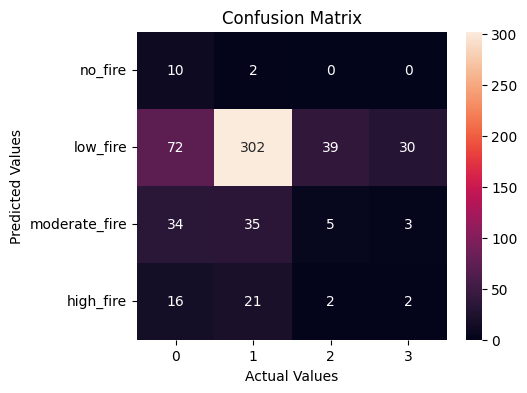

In [ ]:
#confusion matrix (Logistic regression classifier)
cm_logreg = confusion_matrix(Y_test, Y_pred)
print(cm_logreg)

cm_df = pd.DataFrame(cm_logreg, index = ['no_fire','low_fire','moderate_fire','high_fire'],
                     columns=['0','1','2','3'])

#Plotting the confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm_df, annot=True, fmt='g')
plt.title('Confusion Matrix')
plt.ylabel('Predicted Values')
plt.xlabel('Actual Values')
plt.show()

In [ ]:
cm_logreg = confusion_matrix(Y_test, Y_pred)

print('Confusion matrix\n\n', cm_logreg)

print('\nTrue Positives(TP) = ', cm_logreg[0,0])

print('\nTrue Negatives(TN) = ', cm_logreg[1,1])

print('\nFalse Positives(FP) = ', cm_logreg[0,1])

print('\nFalse Negatives(FN) = ', cm_logreg[1,0])

Confusion matrix

 [[ 10   2   0   0]
 [ 72 302  39  30]
 [ 34  35   5   3]
 [ 16  21   2   2]]

True Positives(TP) =  10

True Negatives(TN) =  302

False Positives(FP) =  2

False Negatives(FN) =  72


In [ ]:
#naive bayes new results
nb = class_weight.compute_sample_weight('balanced', Y_train)
nbc = GaussianNB()
nbc.fit(X_train, Y_train, sample_weight=nb)
Y_pred = nbc.predict(X_test)
print(cross_validate(nbc, X_train, Y_train, cv=2))
report = classification_report(Y_test, Y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, Y_pred))

GaussianNB()

{'fit_time': array([0.01005721, 0.01064563]), 'score_time': array([0.00323319, 0.00316811]), 'test_score': array([0.69548872, 0.71939736])}
               precision    recall  f1-score   support

      no_fire     0.0702    0.3333    0.1159        12
     low_fire     0.8319    0.4244    0.5620       443
moderate_fire     0.1489    0.5065    0.2301        77
    high_fire     0.0000    0.0000    0.0000        41

     accuracy                         0.4031       573
    macro avg     0.2627    0.3161    0.2270       573
 weighted avg     0.6646    0.4031    0.4679       573

0.3160515180831208


[[  4   2   6   0]
 [ 34 188 198  23]
 [ 12  21  39   5]
 [  7  15  19   0]]


<Figure size 500x400 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Confusion Matrix')

Text(33.081597222222214, 0.5, 'Predicted Values')

Text(0.5, 14.722222222222216, 'Actual Values')

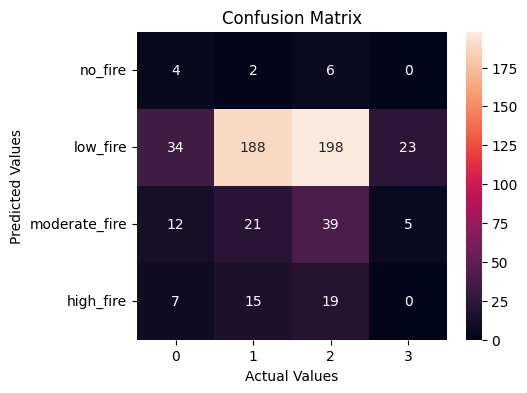

In [ ]:
#confusion matrix (Naive Bayes classifier)
cm_nb = confusion_matrix(Y_test, Y_pred)
print(cm_nb)

cm_df = pd.DataFrame(cm_nb, index = ['no_fire','low_fire','moderate_fire','high_fire'],
                     columns=['0','1','2','3'])

#Plotting the confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm_df, annot=True, fmt='g')
plt.title('Confusion Matrix')
plt.ylabel('Predicted Values')
plt.xlabel('Actual Values')
plt.show()

In [ ]:
cm_nb = confusion_matrix(Y_test, Y_pred)

print('Confusion matrix\n\n', cm_nb)

print('\nTrue Positives(TP) = ', cm_nb[0,0])

print('\nTrue Negatives(TN) = ', cm_nb[1,1])

print('\nFalse Positives(FP) = ', cm_nb[0,1])

print('\nFalse Negatives(FN) = ', cm_nb[1,0])

Confusion matrix

 [[  4   2   6   0]
 [ 34 188 198  23]
 [ 12  21  39   5]
 [  7  15  19   0]]

True Positives(TP) =  4

True Negatives(TN) =  188

False Positives(FP) =  2

False Negatives(FN) =  34


In [ ]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

StandardScaler()

In [ ]:
#knneighbors new results
knc = KNeighborsClassifier(n_neighbors=5, weights='uniform')
knc.fit(X_train,Y_train)
Y_pred = knc.predict(X_test)
print(cross_validate(knc, X_train, Y_train, cv=2))
report = classification_report(Y_test, Y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, Y_pred))

KNeighborsClassifier()

{'fit_time': array([0.00850916, 0.00202394]), 'score_time': array([0.10325313, 0.09709382]), 'test_score': array([0.78195489, 0.79284369])}
               precision    recall  f1-score   support

      no_fire     0.3333    0.0833    0.1333        12
     low_fire     0.7770    0.9594    0.8586       443
moderate_fire     0.2143    0.0390    0.0659        77
    high_fire     0.0000    0.0000    0.0000        41

     accuracy                         0.7487       573
    macro avg     0.3311    0.2704    0.2645       573
 weighted avg     0.6365    0.7487    0.6754       573

0.270415579529575


[[  1   9   0   2]
 [  1 425  11   6]
 [  0  73   3   1]
 [  1  40   0   0]]


<Figure size 500x400 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Confusion Matrix')

Text(33.081597222222214, 0.5, 'Predicted Values')

Text(0.5, 14.722222222222216, 'Actual Values')

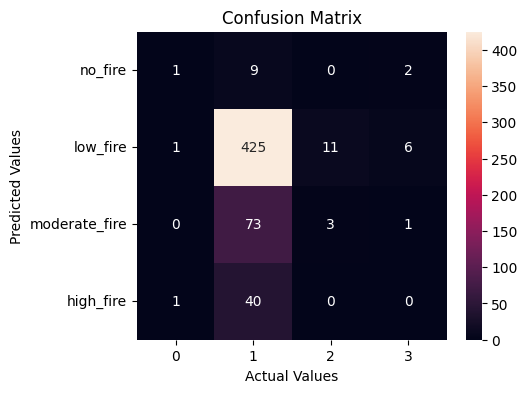

In [ ]:
#confusion matrix (knn classifier)
cm = confusion_matrix(Y_test, Y_pred)
print(cm)

cm_df = pd.DataFrame(cm, index = ['no_fire','low_fire','moderate_fire','high_fire'],
                     columns=['0','1','2','3'])

#Plotting the confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm_df, annot=True, fmt='g')
plt.title('Confusion Matrix')
plt.ylabel('Predicted Values')
plt.xlabel('Actual Values')
plt.show()

In [ ]:
#random forest classifiers new results (previously stored result in overall sheet)
rfc = RandomForestClassifier(n_estimators=100, class_weight='balanced')
rfc.fit(X_train, Y_train)
Y_pred = rfc.predict(X_test)
print(cross_validate(rfc, X_train, Y_train, cv=2))
report = classification_report(Y_test, Y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, Y_pred))

RandomForestClassifier(class_weight='balanced')

{'fit_time': array([0.19056082, 0.19005609]), 'score_time': array([0.01689911, 0.0139451 ]), 'test_score': array([0.79511278, 0.77777778])}
               precision    recall  f1-score   support

      no_fire     0.1667    0.0833    0.1111        12
     low_fire     0.8039    0.9255    0.8604       443
moderate_fire     0.2571    0.1169    0.1607        77
    high_fire     0.1818    0.0976    0.1270        41

     accuracy                         0.7400       573
    macro avg     0.3524    0.3058    0.3148       573
 weighted avg     0.6726    0.7400    0.6982       573

0.3058213316258518


In [ ]:
rfc = RandomForestClassifier(n_estimators=1, class_weight='balanced')
rfc.fit(X_train, Y_train)
Y_pred = rfc.predict(X_test)
print(cross_validate(rfc, X_train, Y_train, cv=2))
report = classification_report(Y_test, Y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, Y_pred))

RandomForestClassifier(class_weight='balanced', n_estimators=1)

{'fit_time': array([0.01234388, 0.00618339]), 'score_time': array([0.00204182, 0.00193   ]), 'test_score': array([0.69548872, 0.73634652])}
               precision    recall  f1-score   support

      no_fire     0.2000    0.1667    0.1818        12
     low_fire     0.8294    0.7901    0.8092       443
moderate_fire     0.1685    0.1948    0.1807        77
    high_fire     0.1731    0.2195    0.1935        41

     accuracy                         0.6562       573
    macro avg     0.3428    0.3428    0.3413       573
 weighted avg     0.6804    0.6562    0.6676       573

0.34276294417102654


In [ ]:
rfc = RandomForestClassifier(n_estimators=5, class_weight='balanced')
rfc.fit(X_train, Y_train)
Y_pred = rfc.predict(X_test)
print(cross_validate(rfc, X_train, Y_train, cv=2))
report = classification_report(Y_test, Y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, Y_pred))

RandomForestClassifier(class_weight='balanced', n_estimators=5)

{'fit_time': array([0.01150823, 0.01112628]), 'score_time': array([0.00176454, 0.00178432]), 'test_score': array([0.7575188 , 0.77777778])}
               precision    recall  f1-score   support

      no_fire     0.1429    0.0833    0.1053        12
     low_fire     0.8082    0.8939    0.8489       443
moderate_fire     0.2500    0.1818    0.2105        77
    high_fire     0.1000    0.0488    0.0656        41

     accuracy                         0.7208       573
    macro avg     0.3253    0.3020    0.3076       573
 weighted avg     0.6686    0.7208    0.6915       573

0.3019592987074956


In [ ]:
rfc = RandomForestClassifier(n_estimators=10, class_weight='balanced')
rfc.fit(X_train, Y_train)
Y_pred = rfc.predict(X_test)
print(cross_validate(rfc, X_train, Y_train, cv=2))
report = classification_report(Y_test, Y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, Y_pred))

RandomForestClassifier(class_weight='balanced', n_estimators=10)

{'fit_time': array([0.03293252, 0.07983875]), 'score_time': array([0.00452471, 0.00631809]), 'test_score': array([0.78007519, 0.77589454])}
               precision    recall  f1-score   support

      no_fire     0.1429    0.0833    0.1053        12
     low_fire     0.8004    0.9233    0.8574       443
moderate_fire     0.2812    0.1169    0.1651        77
    high_fire     0.1304    0.0732    0.0938        41

     accuracy                         0.7365       573
    macro avg     0.3387    0.2992    0.3054       573
 weighted avg     0.6689    0.7365    0.6940       573

0.29915943656446325


In [ ]:
rfc = RandomForestClassifier(n_estimators=25, class_weight='balanced')
rfc.fit(X_train, Y_train)
Y_pred = rfc.predict(X_test)
print(cross_validate(rfc, X_train, Y_train, cv=2))
report = classification_report(Y_test, Y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, Y_pred))

RandomForestClassifier(class_weight='balanced', n_estimators=25)

{'fit_time': array([0.10385633, 0.07657003]), 'score_time': array([0.00638223, 0.00639033]), 'test_score': array([0.78759398, 0.77777778])}
               precision    recall  f1-score   support

      no_fire     0.2500    0.0833    0.1250        12
     low_fire     0.8083    0.9233    0.8620       443
moderate_fire     0.2778    0.1299    0.1770        77
    high_fire     0.2222    0.1463    0.1765        41

     accuracy                         0.7435       573
    macro avg     0.3896    0.3207    0.3351       573
 weighted avg     0.6834    0.7435    0.7054       573

0.32069887273804576


In [ ]:
rfc = RandomForestClassifier(n_estimators=50, class_weight='balanced')
rfc.fit(X_train, Y_train)
Y_pred = rfc.predict(X_test)
print(cross_validate(rfc, X_train, Y_train, cv=2))
report = classification_report(Y_test, Y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, Y_pred))

RandomForestClassifier(class_weight='balanced', n_estimators=50)

{'fit_time': array([0.15145755, 0.14840412]), 'score_time': array([0.01103902, 0.01075196]), 'test_score': array([0.77819549, 0.77777778])}
               precision    recall  f1-score   support

      no_fire     0.2000    0.0833    0.1176        12
     low_fire     0.8134    0.9345    0.8697       443
moderate_fire     0.2941    0.1299    0.1802        77
    high_fire     0.1600    0.0976    0.1212        41

     accuracy                         0.7487       573
    macro avg     0.3669    0.3113    0.3222       573
 weighted avg     0.6840    0.7487    0.7078       573

0.3113254212157202


In [ ]:
#random forest classifiers
rfc = RandomForestClassifier(n_estimators=1,criterion='gini',max_features='sqrt',max_depth=1)
rfc.fit(X_train, Y_train)
Y_pred = rfc.predict(X_test)
print(cross_validate(rfc, X_train, Y_train, cv=2))
report = classification_report(Y_test, Y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, Y_pred))

RandomForestClassifier(max_depth=1, n_estimators=1)

{'fit_time': array([0.00461841, 0.00434327]), 'score_time': array([0.00176167, 0.00159216]), 'test_score': array([0.80075188, 0.80037665])}
               precision    recall  f1-score   support

      no_fire     0.0000    0.0000    0.0000        12
     low_fire     0.7731    1.0000    0.8720       443
moderate_fire     0.0000    0.0000    0.0000        77
    high_fire     0.0000    0.0000    0.0000        41

     accuracy                         0.7731       573
    macro avg     0.1933    0.2500    0.2180       573
 weighted avg     0.5977    0.7731    0.6742       573

0.25


In [ ]:
#random forest classifiers
rfc = RandomForestClassifier(n_estimators=5,criterion='gini',max_features='sqrt',max_depth=1)
rfc.fit(X_train, Y_train)
Y_pred = rfc.predict(X_test)
print(cross_validate(rfc, X_train, Y_train, cv=2))
report = classification_report(Y_test, Y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, Y_pred))

RandomForestClassifier(max_depth=1, n_estimators=5)

{'fit_time': array([0.01533794, 0.01752543]), 'score_time': array([0.00267625, 0.00253224]), 'test_score': array([0.80075188, 0.80037665])}
               precision    recall  f1-score   support

      no_fire     0.0000    0.0000    0.0000        12
     low_fire     0.7731    1.0000    0.8720       443
moderate_fire     0.0000    0.0000    0.0000        77
    high_fire     0.0000    0.0000    0.0000        41

     accuracy                         0.7731       573
    macro avg     0.1933    0.2500    0.2180       573
 weighted avg     0.5977    0.7731    0.6742       573

0.25


In [ ]:
#random forest classifiers
rfc = RandomForestClassifier(n_estimators=10,criterion='gini',max_features='sqrt',max_depth=1)
rfc.fit(X_train, Y_train)
Y_pred = rfc.predict(X_test)
print(cross_validate(rfc, X_train, Y_train, cv=2))
report = classification_report(Y_test, Y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, Y_pred))

RandomForestClassifier(max_depth=1, n_estimators=10)

{'fit_time': array([0.02731347, 0.02634072]), 'score_time': array([0.00347829, 0.00340295]), 'test_score': array([0.80075188, 0.80037665])}
               precision    recall  f1-score   support

      no_fire     0.0000    0.0000    0.0000        12
     low_fire     0.7731    1.0000    0.8720       443
moderate_fire     0.0000    0.0000    0.0000        77
    high_fire     0.0000    0.0000    0.0000        41

     accuracy                         0.7731       573
    macro avg     0.1933    0.2500    0.2180       573
 weighted avg     0.5977    0.7731    0.6742       573

0.25


In [ ]:
#random forest classifiers
rfc = RandomForestClassifier(n_estimators=25,criterion='gini',max_features='sqrt',max_depth=1)
rfc.fit(X_train, Y_train)
Y_pred = rfc.predict(X_test)
print(cross_validate(rfc, X_train, Y_train, cv=2))
report = classification_report(Y_test, Y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, Y_pred))

RandomForestClassifier(max_depth=1, n_estimators=25)

{'fit_time': array([0.06454682, 0.06407118]), 'score_time': array([0.00562501, 0.00577402]), 'test_score': array([0.80075188, 0.80037665])}
               precision    recall  f1-score   support

      no_fire     0.0000    0.0000    0.0000        12
     low_fire     0.7731    1.0000    0.8720       443
moderate_fire     0.0000    0.0000    0.0000        77
    high_fire     0.0000    0.0000    0.0000        41

     accuracy                         0.7731       573
    macro avg     0.1933    0.2500    0.2180       573
 weighted avg     0.5977    0.7731    0.6742       573

0.25


In [ ]:
#random forest classifiers
rfc = RandomForestClassifier(n_estimators=50,criterion='gini',max_features='sqrt',max_depth=1)
rfc.fit(X_train, Y_train)
Y_pred = rfc.predict(X_test)
print(cross_validate(rfc, X_train, Y_train, cv=2))
report = classification_report(Y_test, Y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, Y_pred))

RandomForestClassifier(max_depth=1, n_estimators=50)

{'fit_time': array([0.49799037, 0.26658487]), 'score_time': array([0.01789188, 0.00543952]), 'test_score': array([0.80075188, 0.80037665])}
               precision    recall  f1-score   support

      no_fire     0.0000    0.0000    0.0000        12
     low_fire     0.7731    1.0000    0.8720       443
moderate_fire     0.0000    0.0000    0.0000        77
    high_fire     0.0000    0.0000    0.0000        41

     accuracy                         0.7731       573
    macro avg     0.1933    0.2500    0.2180       573
 weighted avg     0.5977    0.7731    0.6742       573

0.25


In [ ]:
#random forest classifiers
rfc = RandomForestClassifier(n_estimators=1,criterion='gini',max_features='sqrt',max_depth=3)
rfc.fit(X_train, Y_train)
Y_pred = rfc.predict(X_test)
print(cross_validate(rfc, X_train, Y_train, cv=2))
report = classification_report(Y_test, Y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, Y_pred))

RandomForestClassifier(max_depth=3, n_estimators=1)

{'fit_time': array([0.02730393, 0.01343513]), 'score_time': array([0.00245404, 0.00982356]), 'test_score': array([0.80075188, 0.79472693])}
               precision    recall  f1-score   support

      no_fire     0.0000    0.0000    0.0000        12
     low_fire     0.7731    1.0000    0.8720       443
moderate_fire     0.0000    0.0000    0.0000        77
    high_fire     0.0000    0.0000    0.0000        41

     accuracy                         0.7731       573
    macro avg     0.1933    0.2500    0.2180       573
 weighted avg     0.5977    0.7731    0.6742       573

0.25


In [ ]:
#random forest classifiers
rfc = RandomForestClassifier(n_estimators=5,criterion='gini',max_features='sqrt',max_depth=3)
rfc.fit(X_train, Y_train)
Y_pred = rfc.predict(X_test)
print(cross_validate(rfc, X_train, Y_train, cv=2))
report = classification_report(Y_test, Y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, Y_pred))

RandomForestClassifier(max_depth=3, n_estimators=5)

{'fit_time': array([0.07665181, 0.04787683]), 'score_time': array([0.0119071 , 0.00282621]), 'test_score': array([0.80075188, 0.79849341])}
               precision    recall  f1-score   support

      no_fire     0.0000    0.0000    0.0000        12
     low_fire     0.7731    1.0000    0.8720       443
moderate_fire     0.0000    0.0000    0.0000        77
    high_fire     0.0000    0.0000    0.0000        41

     accuracy                         0.7731       573
    macro avg     0.1933    0.2500    0.2180       573
 weighted avg     0.5977    0.7731    0.6742       573

0.25


In [ ]:
#random forest classifiers
rfc = RandomForestClassifier(n_estimators=10,criterion='gini',max_features='sqrt',max_depth=3)
rfc.fit(X_train, Y_train)
Y_pred = rfc.predict(X_test)
print(cross_validate(rfc, X_train, Y_train, cv=2))
report = classification_report(Y_test, Y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, Y_pred))

RandomForestClassifier(max_depth=3, n_estimators=10)

{'fit_time': array([0.02979207, 0.0310936 ]), 'score_time': array([0.00387406, 0.00386906]), 'test_score': array([0.80075188, 0.80037665])}
               precision    recall  f1-score   support

      no_fire     0.0000    0.0000    0.0000        12
     low_fire     0.7731    1.0000    0.8720       443
moderate_fire     0.0000    0.0000    0.0000        77
    high_fire     0.0000    0.0000    0.0000        41

     accuracy                         0.7731       573
    macro avg     0.1933    0.2500    0.2180       573
 weighted avg     0.5977    0.7731    0.6742       573

0.25


In [ ]:
#random forest classifiers
rfc = RandomForestClassifier(n_estimators=25,criterion='gini',max_features='sqrt',max_depth=3)
rfc.fit(X_train, Y_train)
Y_pred = rfc.predict(X_test)
print(cross_validate(rfc, X_train, Y_train, cv=2))
report = classification_report(Y_test, Y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, Y_pred))

RandomForestClassifier(max_depth=3, n_estimators=25)

{'fit_time': array([0.08269501, 0.08381462]), 'score_time': array([0.00636625, 0.0071702 ]), 'test_score': array([0.80075188, 0.80037665])}
               precision    recall  f1-score   support

      no_fire     0.0000    0.0000    0.0000        12
     low_fire     0.7731    1.0000    0.8720       443
moderate_fire     0.0000    0.0000    0.0000        77
    high_fire     0.0000    0.0000    0.0000        41

     accuracy                         0.7731       573
    macro avg     0.1933    0.2500    0.2180       573
 weighted avg     0.5977    0.7731    0.6742       573

0.25


In [ ]:
#random forest classifiers
rfc = RandomForestClassifier(n_estimators=50,criterion='gini',max_features='sqrt',max_depth=3)
rfc.fit(X_train, Y_train)
Y_pred = rfc.predict(X_test)
print(cross_validate(rfc, X_train, Y_train, cv=2))
report = classification_report(Y_test, Y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, Y_pred))

RandomForestClassifier(max_depth=3, n_estimators=50)

{'fit_time': array([0.08545184, 0.08162665]), 'score_time': array([0.01229715, 0.00629163]), 'test_score': array([0.80075188, 0.80037665])}
               precision    recall  f1-score   support

      no_fire     0.0000    0.0000    0.0000        12
     low_fire     0.7731    1.0000    0.8720       443
moderate_fire     0.0000    0.0000    0.0000        77
    high_fire     0.0000    0.0000    0.0000        41

     accuracy                         0.7731       573
    macro avg     0.1933    0.2500    0.2180       573
 weighted avg     0.5977    0.7731    0.6742       573

0.25


In [ ]:
#random forest classifiers
rfc = RandomForestClassifier(n_estimators=1,criterion='gini',max_features='sqrt',max_depth=5)
rfc.fit(X_train, Y_train)
Y_pred = rfc.predict(X_test)
print(cross_validate(rfc, X_train, Y_train, cv=2))
report = classification_report(Y_test, Y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, Y_pred))

RandomForestClassifier(max_depth=5, n_estimators=1)

{'fit_time': array([0.00675845, 0.01375604]), 'score_time': array([0.00272799, 0.0037477 ]), 'test_score': array([0.7612782 , 0.78719397])}
               precision    recall  f1-score   support

      no_fire     0.0000    0.0000    0.0000        12
     low_fire     0.7760    0.9932    0.8713       443
moderate_fire     0.0000    0.0000    0.0000        77
    high_fire     0.3333    0.0244    0.0455        41

     accuracy                         0.7696       573
    macro avg     0.2773    0.2544    0.2292       573
 weighted avg     0.6238    0.7696    0.6769       573

0.2544045587182734


In [ ]:
#random forest classifiers
rfc = RandomForestClassifier(n_estimators=5,criterion='gini',max_features='sqrt',max_depth=5)
rfc.fit(X_train, Y_train)
Y_pred = rfc.predict(X_test)
print(cross_validate(rfc, X_train, Y_train, cv=2))
report = classification_report(Y_test, Y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, Y_pred))

RandomForestClassifier(max_depth=5, n_estimators=5)

{'fit_time': array([0.02330732, 0.01756382]), 'score_time': array([0.00311255, 0.00357747]), 'test_score': array([0.80075188, 0.7740113 ])}
               precision    recall  f1-score   support

      no_fire     0.0000    0.0000    0.0000        12
     low_fire     0.7768    0.9977    0.8735       443
moderate_fire     0.3333    0.0130    0.0250        77
    high_fire     1.0000    0.0244    0.0476        41

     accuracy                         0.7749       573
    macro avg     0.5275    0.2588    0.2365       573
 weighted avg     0.7169    0.7749    0.6821       573

0.2587799801365842


In [ ]:
#random forest classifiers
rfc = RandomForestClassifier(n_estimators=10,criterion='gini',max_features='sqrt',max_depth=5)
rfc.fit(X_train, Y_train)
Y_pred = rfc.predict(X_test)
print(cross_validate(rfc, X_train, Y_train, cv=2))
report = classification_report(Y_test, Y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, Y_pred))

RandomForestClassifier(max_depth=5, n_estimators=10)

{'fit_time': array([0.06882286, 0.06970406]), 'score_time': array([0.01106691, 0.01188803]), 'test_score': array([0.79323308, 0.79472693])}
               precision    recall  f1-score   support

      no_fire     0.0000    0.0000    0.0000        12
     low_fire     0.7750    0.9955    0.8715       443
moderate_fire     0.0000    0.0000    0.0000        77
    high_fire     0.0000    0.0000    0.0000        41

     accuracy                         0.7696       573
    macro avg     0.1938    0.2489    0.2179       573
 weighted avg     0.5992    0.7696    0.6738       573

0.24887133182844243


In [ ]:
#random forest classifiers
rfc = RandomForestClassifier(n_estimators=25,criterion='gini',max_features='sqrt',max_depth=5)
rfc.fit(X_train, Y_train)
Y_pred = rfc.predict(X_test)
print(cross_validate(rfc, X_train, Y_train, cv=2))
report = classification_report(Y_test, Y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, Y_pred))

RandomForestClassifier(max_depth=5, n_estimators=25)

{'fit_time': array([0.07227778, 0.07568169]), 'score_time': array([0.00680804, 0.00595713]), 'test_score': array([0.80263158, 0.79096045])}
               precision    recall  f1-score   support

      no_fire     0.0000    0.0000    0.0000        12
     low_fire     0.7758    1.0000    0.8738       443
moderate_fire     0.0000    0.0000    0.0000        77
    high_fire     0.5000    0.0244    0.0465        41

     accuracy                         0.7749       573
    macro avg     0.3190    0.2561    0.2301       573
 weighted avg     0.6356    0.7749    0.6789       573

0.25609756097560976


In [ ]:
#random forest classifiers
rfc = RandomForestClassifier(n_estimators=50,criterion='gini',max_features='sqrt',max_depth=5)
rfc.fit(X_train, Y_train)
Y_pred = rfc.predict(X_test)
print(cross_validate(rfc, X_train, Y_train, cv=2))
report = classification_report(Y_test, Y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, Y_pred))

RandomForestClassifier(max_depth=5, n_estimators=50)

{'fit_time': array([0.15848732, 0.143471  ]), 'score_time': array([0.0112052 , 0.01053929]), 'test_score': array([0.79887218, 0.78531073])}
               precision    recall  f1-score   support

      no_fire     0.0000    0.0000    0.0000        12
     low_fire     0.7745    1.0000    0.8729       443
moderate_fire     0.0000    0.0000    0.0000        77
    high_fire     1.0000    0.0244    0.0476        41

     accuracy                         0.7749       573
    macro avg     0.4436    0.2561    0.2301       573
 weighted avg     0.6703    0.7749    0.6783       573

0.25609756097560976


In [ ]:
#random forest classifiers
rfc = RandomForestClassifier(n_estimators=1,criterion='gini',max_features='sqrt',max_depth=7)
rfc.fit(X_train, Y_train)
Y_pred = rfc.predict(X_test)
print(cross_validate(rfc, X_train, Y_train, cv=2))
report = classification_report(Y_test, Y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, Y_pred))

RandomForestClassifier(max_depth=7, n_estimators=1)

{'fit_time': array([0.01301575, 0.01388764]), 'score_time': array([0.00189662, 0.00186658]), 'test_score': array([0.7575188 , 0.75141243])}
               precision    recall  f1-score   support

      no_fire     0.0000    0.0000    0.0000        12
     low_fire     0.7883    0.9413    0.8580       443
moderate_fire     0.1500    0.0390    0.0619        77
    high_fire     0.1429    0.0488    0.0727        41

     accuracy                         0.7365       573
    macro avg     0.2703    0.2573    0.2482       573
 weighted avg     0.6398    0.7365    0.6769       573

0.25726269546123093


In [ ]:
#random forest classifiers
rfc = RandomForestClassifier(n_estimators=5,criterion='gini',max_features='sqrt',max_depth=7)
rfc.fit(X_train, Y_train)
Y_pred = rfc.predict(X_test)
print(cross_validate(rfc, X_train, Y_train, cv=2))
report = classification_report(Y_test, Y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, Y_pred))

RandomForestClassifier(max_depth=7, n_estimators=5)

{'fit_time': array([0.01843476, 0.01671648]), 'score_time': array([0.0029645 , 0.00293493]), 'test_score': array([0.78383459, 0.77589454])}
               precision    recall  f1-score   support

      no_fire     0.0000    0.0000    0.0000        12
     low_fire     0.7873    0.9774    0.8721       443
moderate_fire     0.1579    0.0390    0.0625        77
    high_fire     0.3333    0.0244    0.0455        41

     accuracy                         0.7627       573
    macro avg     0.3196    0.2602    0.2450       573
 weighted avg     0.6537    0.7627    0.6859       573

0.2601944798580817


In [ ]:
#random forest classifiers
rfc = RandomForestClassifier(n_estimators=10,criterion='gini',max_features='sqrt',max_depth=7)
rfc.fit(X_train, Y_train)
Y_pred = rfc.predict(X_test)
print(cross_validate(rfc, X_train, Y_train, cv=2))
report = classification_report(Y_test, Y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, Y_pred))

RandomForestClassifier(max_depth=7, n_estimators=10)

{'fit_time': array([0.0822711 , 0.08004141]), 'score_time': array([0.00361323, 0.00389767]), 'test_score': array([0.78759398, 0.78154426])}
               precision    recall  f1-score   support

      no_fire     0.0000    0.0000    0.0000        12
     low_fire     0.7843    0.9932    0.8765       443
moderate_fire     0.3333    0.0390    0.0698        77
    high_fire     0.6667    0.0488    0.0909        41

     accuracy                         0.7766       573
    macro avg     0.4461    0.2702    0.2593       573
 weighted avg     0.6989    0.7766    0.6935       573

0.2702423794341429


In [ ]:
#random forest classifiers
rfc = RandomForestClassifier(n_estimators=25,criterion='gini',max_features='sqrt',max_depth=7)
rfc.fit(X_train, Y_train)
Y_pred = rfc.predict(X_test)
print(cross_validate(rfc, X_train, Y_train, cv=2))
report = classification_report(Y_test, Y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, Y_pred))

RandomForestClassifier(max_depth=7, n_estimators=25)

{'fit_time': array([0.05803394, 0.0515027 ]), 'score_time': array([0.00428677, 0.00460482]), 'test_score': array([0.79887218, 0.78907721])}
               precision    recall  f1-score   support

      no_fire     0.0000    0.0000    0.0000        12
     low_fire     0.7782    0.9977    0.8744       443
moderate_fire     0.0000    0.0000    0.0000        77
    high_fire     0.5000    0.0244    0.0465        41

     accuracy                         0.7731       573
    macro avg     0.3195    0.2555    0.2302       573
 weighted avg     0.6374    0.7731    0.6793       573

0.255533226889831


In [ ]:
#random forest classifiers
rfc = RandomForestClassifier(n_estimators=50,criterion='gini',max_features='sqrt',max_depth=7)
rfc.fit(X_train, Y_train)
Y_pred = rfc.predict(X_test)
print(cross_validate(rfc, X_train, Y_train, cv=2))
report = classification_report(Y_test, Y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, Y_pred))

RandomForestClassifier(max_depth=7, n_estimators=50)

{'fit_time': array([0.17954159, 0.1713109 ]), 'score_time': array([0.01073742, 0.01175213]), 'test_score': array([0.79699248, 0.78154426])}
               precision    recall  f1-score   support

      no_fire     0.0000    0.0000    0.0000        12
     low_fire     0.7788    0.9932    0.8730       443
moderate_fire     0.0000    0.0000    0.0000        77
    high_fire     0.3333    0.0244    0.0455        41

     accuracy                         0.7696       573
    macro avg     0.2780    0.2544    0.2296       573
 weighted avg     0.6259    0.7696    0.6782       573

0.2544045587182734


In [ ]:
#random forest classifiers
rfc = RandomForestClassifier(n_estimators=1,criterion='gini',max_features='sqrt',max_depth=9)
rfc.fit(X_train, Y_train)
Y_pred = rfc.predict(X_test)
print(cross_validate(rfc, X_train, Y_train, cv=2))
report = classification_report(Y_test, Y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, Y_pred))

RandomForestClassifier(max_depth=9, n_estimators=1)

{'fit_time': array([0.00578403, 0.00651884]), 'score_time': array([0.00211596, 0.00237155]), 'test_score': array([0.71428571, 0.71186441])}
               precision    recall  f1-score   support

      no_fire     0.1111    0.0833    0.0952        12
     low_fire     0.8106    0.8984    0.8522       443
moderate_fire     0.2830    0.1948    0.2308        77
    high_fire     0.2500    0.1220    0.1639        41

     accuracy                         0.7312       573
    macro avg     0.3637    0.3246    0.3355       573
 weighted avg     0.6849    0.7312    0.7036       573

0.3246274030526357


In [ ]:
#random forest classifiers
rfc = RandomForestClassifier(n_estimators=5,criterion='gini',max_features='sqrt',max_depth=9)
rfc.fit(X_train, Y_train)
Y_pred = rfc.predict(X_test)
print(cross_validate(rfc, X_train, Y_train, cv=2))
report = classification_report(Y_test, Y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, Y_pred))

RandomForestClassifier(max_depth=9, n_estimators=5)

{'fit_time': array([0.02335835, 0.01925111]), 'score_time': array([0.00316453, 0.00313711]), 'test_score': array([0.78383459, 0.78154426])}
               precision    recall  f1-score   support

      no_fire     0.3333    0.0833    0.1333        12
     low_fire     0.8030    0.9661    0.8770       443
moderate_fire     0.3810    0.1039    0.1633        77
    high_fire     0.3125    0.1220    0.1754        41

     accuracy                         0.7714       573
    macro avg     0.4574    0.3188    0.3373       573
 weighted avg     0.7014    0.7714    0.7154       573

0.3188301528987264


In [ ]:
#random forest classifiers
rfc = RandomForestClassifier(n_estimators=10,criterion='gini',max_features='sqrt',max_depth=9)
rfc.fit(X_train, Y_train)
Y_pred = rfc.predict(X_test)
print(cross_validate(rfc, X_train, Y_train, cv=2))
report = classification_report(Y_test, Y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, Y_pred))

RandomForestClassifier(max_depth=9, n_estimators=10)

{'fit_time': array([0.05194449, 0.05822945]), 'score_time': array([0.00912929, 0.00688076]), 'test_score': array([0.78947368, 0.77024482])}
               precision    recall  f1-score   support

      no_fire     0.0000    0.0000    0.0000        12
     low_fire     0.7982    0.9819    0.8806       443
moderate_fire     0.2857    0.0779    0.1224        77
    high_fire     0.4000    0.0488    0.0870        41

     accuracy                         0.7731       573
    macro avg     0.3710    0.2772    0.2725       573
 weighted avg     0.6841    0.7731    0.7035       573

0.2771609687455088


In [ ]:
#random forest classifiers
rfc = RandomForestClassifier(n_estimators=25,criterion='gini',max_features='sqrt',max_depth=9)
rfc.fit(X_train, Y_train)
Y_pred = rfc.predict(X_test)
print(cross_validate(rfc, X_train, Y_train, cv=2))
report = classification_report(Y_test, Y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, Y_pred))

RandomForestClassifier(max_depth=9, n_estimators=25)

{'fit_time': array([0.36203074, 0.26203179]), 'score_time': array([0.03728151, 0.00656867]), 'test_score': array([0.78759398, 0.76836158])}
               precision    recall  f1-score   support

      no_fire     0.0000    0.0000    0.0000        12
     low_fire     0.7906    0.9887    0.8786       443
moderate_fire     0.3333    0.0519    0.0899        77
    high_fire     0.5714    0.0976    0.1667        41

     accuracy                         0.7784       573
    macro avg     0.4238    0.2846    0.2838       573
 weighted avg     0.6969    0.7784    0.7033       573

0.2845555864605581


In [ ]:
#random forest classifiers
rfc = RandomForestClassifier(n_estimators=50,criterion='gini',max_features='sqrt',max_depth=9)
rfc.fit(X_train, Y_train)
Y_pred = rfc.predict(X_test)
print(cross_validate(rfc, X_train, Y_train, cv=2))
report = classification_report(Y_test, Y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, Y_pred))

RandomForestClassifier(max_depth=9, n_estimators=50)

{'fit_time': array([0.32166171, 0.33080983]), 'score_time': array([0.02127886, 0.0189755 ]), 'test_score': array([0.78947368, 0.77966102])}
               precision    recall  f1-score   support

      no_fire     0.0000    0.0000    0.0000        12
     low_fire     0.7874    0.9865    0.8758       443
moderate_fire     0.2727    0.0390    0.0682        77
    high_fire     0.4286    0.0732    0.1250        41

     accuracy                         0.7731       573
    macro avg     0.3722    0.2746    0.2672       573
 weighted avg     0.6761    0.7731    0.6952       573

0.2746469381524163


####Multilayer Perceptron (MLP)

In [ ]:
# Multilayer Perceptron
mlp_clf = MLPClassifier(hidden_layer_sizes=(100),max_iter = 200,activation = 'relu', solver = 'adam')
mlp_clf.fit(X_train, Y_train)
y_pred = mlp_clf.predict(X_test)
print(cross_validate(mlp_clf, X_train, Y_train, cv = 2))
report = classification_report(Y_test, Y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, Y_pred))

MLPClassifier(hidden_layer_sizes=100)

{'fit_time': array([0.72695732, 0.7327075 ]), 'score_time': array([0.00655079, 0.00215006]), 'test_score': array([0.78947368, 0.79849341])}
               precision    recall  f1-score   support

      no_fire     0.0000    0.0000    0.0000        12
     low_fire     0.7874    0.9865    0.8758       443
moderate_fire     0.2727    0.0390    0.0682        77
    high_fire     0.4286    0.0732    0.1250        41

     accuracy                         0.7731       573
    macro avg     0.3722    0.2746    0.2672       573
 weighted avg     0.6761    0.7731    0.6952       573

0.2746469381524163


In [ ]:
# Multilayer Perceptron (New)stored in overall sheet
mlp_clf = MLPClassifier(hidden_layer_sizes=(100),max_iter = 1000,\
                        activation = 'relu', solver = 'adam', \
                        learning_rate='constant', alpha=0.001)
mlp_clf.fit(X_train, Y_train)
y_pred = mlp_clf.predict(X_test)
print(cross_validate(mlp_clf, X_train, Y_train, cv = 2))
report = classification_report(Y_test, Y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, Y_pred))

MLPClassifier(alpha=0.001, hidden_layer_sizes=100, max_iter=1000)

{'fit_time': array([3.99291539, 3.23035979]), 'score_time': array([0.00211143, 0.00675392]), 'test_score': array([0.78195489, 0.7645951 ])}
               precision    recall  f1-score   support

      no_fire     0.0000    0.0000    0.0000        12
     low_fire     0.7874    0.9865    0.8758       443
moderate_fire     0.2727    0.0390    0.0682        77
    high_fire     0.4286    0.0732    0.1250        41

     accuracy                         0.7731       573
    macro avg     0.3722    0.2746    0.2672       573
 weighted avg     0.6761    0.7731    0.6952       573

0.2746469381524163


In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV

In [ ]:
parameters = {'hidden_layer_sizes': [100, ], 'activation': ['relu'], 'solver': ['adam'],
              'alpha': [0.001], 'learning_rate': ['constant'], 'max_iter': [1]}
mlp_gs_cv = MLPClassifier()
clf = GridSearchCV(mlp_gs_cv, param_grid=parameters, n_jobs=-1, cv=2)
clf.fit(X_train, Y_train)
y_pred = clf.predict(X_test)
report = classification_report(Y_test, Y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, Y_pred))

GridSearchCV(cv=2, estimator=MLPClassifier(), n_jobs=-1,
             param_grid={'activation': ['relu'], 'alpha': [0.001],
                         'hidden_layer_sizes': [100],
                         'learning_rate': ['constant'], 'max_iter': [1],
                         'solver': ['adam']})

               precision    recall  f1-score   support

      no_fire     0.0000    0.0000    0.0000        12
     low_fire     0.7874    0.9865    0.8758       443
moderate_fire     0.2727    0.0390    0.0682        77
    high_fire     0.4286    0.0732    0.1250        41

     accuracy                         0.7731       573
    macro avg     0.3722    0.2746    0.2672       573
 weighted avg     0.6761    0.7731    0.6952       573

0.2746469381524163


##MLP new hyper-parameter tuning based on alpha parameter

In [ ]:
# Multilayer Perceptron alpha 0.1
mlp_clf = MLPClassifier(hidden_layer_sizes=(100),max_iter = 1000,\
                        activation = 'relu', solver = 'adam', \
                        learning_rate='constant', alpha=0.1)
mlp_clf.fit(X_train, Y_train)
y_pred = mlp_clf.predict(X_test)
print(cross_validate(mlp_clf, X_train, Y_train, cv = 2))
report = classification_report(Y_test, y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, y_pred))

MLPClassifier(alpha=0.1, hidden_layer_sizes=100, max_iter=1000)

{'fit_time': array([1.33125806, 0.81829572]), 'score_time': array([0.00124764, 0.00224566]), 'test_score': array([0.78571429, 0.79096045])}
               precision    recall  f1-score   support

      no_fire     0.0000    0.0000    0.0000        12
     low_fire     0.7727    0.9977    0.8709       443
moderate_fire     0.0000    0.0000    0.0000        77
    high_fire     0.0000    0.0000    0.0000        41

     accuracy                         0.7714       573
    macro avg     0.1932    0.2494    0.2177       573
 weighted avg     0.5974    0.7714    0.6733       573

0.24943566591422123


In [ ]:
# Multilayer Perceptron alpha 0.5
mlp_clf = MLPClassifier(hidden_layer_sizes=(100),max_iter = 1000,\
                        activation = 'relu', solver = 'adam', \
                        learning_rate='constant', alpha=0.5)
mlp_clf.fit(X_train, Y_train)
y_pred = mlp_clf.predict(X_test)
print(cross_validate(mlp_clf, X_train, Y_train, cv = 2))
report = classification_report(Y_test, y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, y_pred))

MLPClassifier(alpha=0.5, hidden_layer_sizes=100, max_iter=1000)

{'fit_time': array([0.41921496, 0.49285889]), 'score_time': array([0.00121284, 0.00192165]), 'test_score': array([0.78759398, 0.79849341])}
               precision    recall  f1-score   support

      no_fire     0.0000    0.0000    0.0000        12
     low_fire     0.7731    1.0000    0.8720       443
moderate_fire     0.0000    0.0000    0.0000        77
    high_fire     0.0000    0.0000    0.0000        41

     accuracy                         0.7731       573
    macro avg     0.1933    0.2500    0.2180       573
 weighted avg     0.5977    0.7731    0.6742       573

0.25


In [ ]:
# Multilayer Perceptron 0.8
mlp_clf = MLPClassifier(hidden_layer_sizes=(100),max_iter = 1000,\
                        activation = 'relu', solver = 'adam', \
                        learning_rate='constant', alpha=0.8)
mlp_clf.fit(X_train, Y_train)
y_pred = mlp_clf.predict(X_test)
print(cross_validate(mlp_clf, X_train, Y_train, cv = 2))
report = classification_report(Y_test, y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, y_pred))

MLPClassifier(alpha=0.8, hidden_layer_sizes=100, max_iter=1000)

{'fit_time': array([0.43611312, 0.62630844]), 'score_time': array([0.00122166, 0.00127745]), 'test_score': array([0.79135338, 0.80037665])}
               precision    recall  f1-score   support

      no_fire     0.0000    0.0000    0.0000        12
     low_fire     0.7731    1.0000    0.8720       443
moderate_fire     0.0000    0.0000    0.0000        77
    high_fire     0.0000    0.0000    0.0000        41

     accuracy                         0.7731       573
    macro avg     0.1933    0.2500    0.2180       573
 weighted avg     0.5977    0.7731    0.6742       573

0.25


In [ ]:
# Multilayer Perceptron with alpha 0.01
mlp_clf = MLPClassifier(hidden_layer_sizes=(100),max_iter = 1000,\
                        activation = 'relu', solver = 'adam', \
                        learning_rate='constant', alpha=0.01)
mlp_clf.fit(X_train, Y_train)
y_pred = mlp_clf.predict(X_test)
print(cross_validate(mlp_clf, X_train, Y_train, cv = 2))
report = classification_report(Y_test, y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, y_pred))

MLPClassifier(alpha=0.01, hidden_layer_sizes=100, max_iter=1000)

{'fit_time': array([1.79775643, 1.35993195]), 'score_time': array([0.00150967, 0.00194097]), 'test_score': array([0.78759398, 0.76647834])}
               precision    recall  f1-score   support

      no_fire     0.0000    0.0000    0.0000        12
     low_fire     0.7723    0.9955    0.8698       443
moderate_fire     0.0000    0.0000    0.0000        77
    high_fire     0.0000    0.0000    0.0000        41

     accuracy                         0.7696       573
    macro avg     0.1931    0.2489    0.2175       573
 weighted avg     0.5971    0.7696    0.6725       573

0.24887133182844243


In [ ]:
# Multilayer Perceptron with alpha 0.05
mlp_clf = MLPClassifier(hidden_layer_sizes=(100),max_iter = 1000,\
                        activation = 'relu', solver = 'adam', \
                        learning_rate='constant', alpha=0.05)
mlp_clf.fit(X_train, Y_train)
y_pred = mlp_clf.predict(X_test)
print(cross_validate(mlp_clf, X_train, Y_train, cv = 2))
report = classification_report(Y_test, y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, y_pred))

MLPClassifier(alpha=0.05, hidden_layer_sizes=100, max_iter=1000)

{'fit_time': array([1.3477788, 1.3059597]), 'score_time': array([0.00160742, 0.00131488]), 'test_score': array([0.78195489, 0.76836158])}
               precision    recall  f1-score   support

      no_fire     0.0000    0.0000    0.0000        12
     low_fire     0.7727    0.9977    0.8709       443
moderate_fire     0.0000    0.0000    0.0000        77
    high_fire     0.0000    0.0000    0.0000        41

     accuracy                         0.7714       573
    macro avg     0.1932    0.2494    0.2177       573
 weighted avg     0.5974    0.7714    0.6733       573

0.24943566591422123


In [ ]:
# Multilayer Perceptron with alpha 0.08
mlp_clf = MLPClassifier(hidden_layer_sizes=(100),max_iter = 1000,\
                        activation = 'relu', solver = 'adam', \
                        learning_rate='constant', alpha=0.08)
mlp_clf.fit(X_train, Y_train)
y_pred = mlp_clf.predict(X_test)
print(cross_validate(mlp_clf, X_train, Y_train, cv = 2))
report = classification_report(Y_test, y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, y_pred))

MLPClassifier(alpha=0.08, hidden_layer_sizes=100, max_iter=1000)

{'fit_time': array([1.28485799, 1.20914459]), 'score_time': array([0.00159311, 0.00125694]), 'test_score': array([0.78383459, 0.77589454])}
               precision    recall  f1-score   support

      no_fire     0.0000    0.0000    0.0000        12
     low_fire     0.7727    0.9977    0.8709       443
moderate_fire     0.0000    0.0000    0.0000        77
    high_fire     0.0000    0.0000    0.0000        41

     accuracy                         0.7714       573
    macro avg     0.1932    0.2494    0.2177       573
 weighted avg     0.5974    0.7714    0.6733       573

0.24943566591422123


In [ ]:
# Multilayer Perceptron with alpha 0.001
mlp_clf = MLPClassifier(hidden_layer_sizes=(100),max_iter = 1000,\
                        activation = 'relu', solver = 'adam', \
                        learning_rate='constant', alpha=0.001)
mlp_clf.fit(X_train, Y_train)
y_pred = mlp_clf.predict(X_test)
print(cross_validate(mlp_clf, X_train, Y_train, cv = 2))
report = classification_report(Y_test, y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, y_pred))

MLPClassifier(alpha=0.001, hidden_layer_sizes=100, max_iter=1000)

{'fit_time': array([1.81578159, 1.42364836]), 'score_time': array([0.00605774, 0.00192261]), 'test_score': array([0.78571429, 0.76836158])}
               precision    recall  f1-score   support

      no_fire     0.0000    0.0000    0.0000        12
     low_fire     0.7727    0.9977    0.8709       443
moderate_fire     0.0000    0.0000    0.0000        77
    high_fire     0.0000    0.0000    0.0000        41

     accuracy                         0.7714       573
    macro avg     0.1932    0.2494    0.2177       573
 weighted avg     0.5974    0.7714    0.6733       573

0.24943566591422123


In [ ]:
# Multilayer Perceptron (New)stored in overall sheet
mlp_clf = MLPClassifier(hidden_layer_sizes=(100),max_iter = 1000,\
                        activation = 'relu', solver = 'adam', \
                        learning_rate='constant', alpha=0.005)
mlp_clf.fit(X_train, Y_train)
y_pred = mlp_clf.predict(X_test)
print(cross_validate(mlp_clf, X_train, Y_train, cv = 2))
report = classification_report(Y_test, y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, y_pred))

MLPClassifier(alpha=0.005, hidden_layer_sizes=100, max_iter=1000)

{'fit_time': array([1.33636284, 1.43046117]), 'score_time': array([0.00533223, 0.00626206]), 'test_score': array([0.78195489, 0.77777778])}
               precision    recall  f1-score   support

      no_fire     0.0000    0.0000    0.0000        12
     low_fire     0.7737    0.9955    0.8707       443
moderate_fire     0.5000    0.0130    0.0253        77
    high_fire     0.0000    0.0000    0.0000        41

     accuracy                         0.7714       573
    macro avg     0.3184    0.2521    0.2240       573
 weighted avg     0.6653    0.7714    0.6765       573

0.2521180850751957


In [ ]:
# Multilayer Perceptron (New)stored in overall sheet
mlp_clf = MLPClassifier(hidden_layer_sizes=(100),max_iter = 1000,\
                        activation = 'relu', solver = 'adam', \
                        learning_rate='constant', alpha=0.008)
mlp_clf.fit(X_train, Y_train)
y_pred = mlp_clf.predict(X_test)
print(cross_validate(mlp_clf, X_train, Y_train, cv = 2))
report = classification_report(Y_test, y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, y_pred))

MLPClassifier(alpha=0.008, hidden_layer_sizes=100, max_iter=1000)

{'fit_time': array([1.31216574, 1.15493512]), 'score_time': array([0.00137329, 0.0019269 ]), 'test_score': array([0.78383459, 0.77212806])}
               precision    recall  f1-score   support

      no_fire     0.0000    0.0000    0.0000        12
     low_fire     0.7727    0.9977    0.8709       443
moderate_fire     0.0000    0.0000    0.0000        77
    high_fire     0.0000    0.0000    0.0000        41

     accuracy                         0.7714       573
    macro avg     0.1932    0.2494    0.2177       573
 weighted avg     0.5974    0.7714    0.6733       573

0.24943566591422123


##MLP parameter tuning on hidden layers w.r.t alpha 0.8(Max)

In [ ]:
# Multilayer Perceptron 0.8
mlp_clf = MLPClassifier(hidden_layer_sizes=(20),max_iter = 1000,\
                        activation = 'relu', solver = 'adam', \
                        learning_rate='constant', alpha=0.8)
mlp_clf.fit(X_train, Y_train)
y_pred = mlp_clf.predict(X_test)
print(cross_validate(mlp_clf, X_train, Y_train, cv = 2))
report = classification_report(Y_test, y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, y_pred))

MLPClassifier(alpha=0.8, hidden_layer_sizes=20, max_iter=1000)

{'fit_time': array([0.98321581, 1.089221  ]), 'score_time': array([0.00442982, 0.02779436]), 'test_score': array([0.79323308, 0.80037665])}
               precision    recall  f1-score   support

      no_fire     0.0000    0.0000    0.0000        12
     low_fire     0.7731    1.0000    0.8720       443
moderate_fire     0.0000    0.0000    0.0000        77
    high_fire     0.0000    0.0000    0.0000        41

     accuracy                         0.7731       573
    macro avg     0.1933    0.2500    0.2180       573
 weighted avg     0.5977    0.7731    0.6742       573

0.25


In [ ]:
# Multilayer Perceptron 0.8
mlp_clf = MLPClassifier(hidden_layer_sizes=(40),max_iter = 1000,\
                        activation = 'relu', solver = 'adam', \
                        learning_rate='constant', alpha=0.8)
mlp_clf.fit(X_train, Y_train)
y_pred = mlp_clf.predict(X_test)
print(cross_validate(mlp_clf, X_train, Y_train, cv = 2))
report = classification_report(Y_test, y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, y_pred))

MLPClassifier(alpha=0.8, hidden_layer_sizes=40, max_iter=1000)

{'fit_time': array([0.8100729 , 0.73423576]), 'score_time': array([0.00132203, 0.00167251]), 'test_score': array([0.78947368, 0.80037665])}
               precision    recall  f1-score   support

      no_fire     0.0000    0.0000    0.0000        12
     low_fire     0.7731    1.0000    0.8720       443
moderate_fire     0.0000    0.0000    0.0000        77
    high_fire     0.0000    0.0000    0.0000        41

     accuracy                         0.7731       573
    macro avg     0.1933    0.2500    0.2180       573
 weighted avg     0.5977    0.7731    0.6742       573

0.25


In [ ]:
# Multilayer Perceptron 0.8
mlp_clf = MLPClassifier(hidden_layer_sizes=(60),max_iter = 1000,\
                        activation = 'relu', solver = 'adam', \
                        learning_rate='constant', alpha=0.8)
mlp_clf.fit(X_train, Y_train)
y_pred = mlp_clf.predict(X_test)
print(cross_validate(mlp_clf, X_train, Y_train, cv = 2))
report = classification_report(Y_test, y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, y_pred))

MLPClassifier(alpha=0.8, hidden_layer_sizes=60, max_iter=1000)

{'fit_time': array([0.88238645, 1.30864358]), 'score_time': array([0.0014751 , 0.00119543]), 'test_score': array([0.79135338, 0.79849341])}
               precision    recall  f1-score   support

      no_fire     0.0000    0.0000    0.0000        12
     low_fire     0.7731    1.0000    0.8720       443
moderate_fire     0.0000    0.0000    0.0000        77
    high_fire     0.0000    0.0000    0.0000        41

     accuracy                         0.7731       573
    macro avg     0.1933    0.2500    0.2180       573
 weighted avg     0.5977    0.7731    0.6742       573

0.25


In [ ]:
# Multilayer Perceptron 0.8
mlp_clf = MLPClassifier(hidden_layer_sizes=(80),max_iter = 1000,\
                        activation = 'relu', solver = 'adam', \
                        learning_rate='constant', alpha=0.8)
mlp_clf.fit(X_train, Y_train)
y_pred = mlp_clf.predict(X_test)
print(cross_validate(mlp_clf, X_train, Y_train, cv = 2))
report = classification_report(Y_test, y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, y_pred))

MLPClassifier(alpha=0.8, hidden_layer_sizes=80, max_iter=1000)

{'fit_time': array([0.54880261, 0.56961083]), 'score_time': array([0.00133228, 0.00133753]), 'test_score': array([0.79135338, 0.80037665])}
               precision    recall  f1-score   support

      no_fire     0.0000    0.0000    0.0000        12
     low_fire     0.7731    1.0000    0.8720       443
moderate_fire     0.0000    0.0000    0.0000        77
    high_fire     0.0000    0.0000    0.0000        41

     accuracy                         0.7731       573
    macro avg     0.1933    0.2500    0.2180       573
 weighted avg     0.5977    0.7731    0.6742       573

0.25


In [ ]:
# Multilayer Perceptron 0.8
mlp_clf = MLPClassifier(hidden_layer_sizes=(100),max_iter = 1000,\
                        activation = 'relu', solver = 'adam', \
                        learning_rate='constant', alpha=0.8)
mlp_clf.fit(X_train, Y_train)
y_pred = mlp_clf.predict(X_test)
print(cross_validate(mlp_clf, X_train, Y_train, cv = 2))
report = classification_report(Y_test, y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, y_pred))

MLPClassifier(alpha=0.8, hidden_layer_sizes=100, max_iter=1000)

{'fit_time': array([0.58803654, 0.85752559]), 'score_time': array([0.00660467, 0.0038867 ]), 'test_score': array([0.79135338, 0.80037665])}
               precision    recall  f1-score   support

      no_fire     0.0000    0.0000    0.0000        12
     low_fire     0.7731    1.0000    0.8720       443
moderate_fire     0.0000    0.0000    0.0000        77
    high_fire     0.0000    0.0000    0.0000        41

     accuracy                         0.7731       573
    macro avg     0.1933    0.2500    0.2180       573
 weighted avg     0.5977    0.7731    0.6742       573

0.25


In [39]:
# Multilayer Perceptron 0.8
mlp_clf = MLPClassifier(hidden_layer_sizes=(120),max_iter = 1000,\
                        activation = 'relu', solver = 'adam', \
                        learning_rate='constant', alpha=0.8)
mlp_clf.fit(X_train, Y_train)
y_pred = mlp_clf.predict(X_test)
print(cross_validate(mlp_clf, X_train, Y_train, cv = 2))
report = classification_report(Y_test, y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, y_pred))

MLPClassifier(alpha=0.8, hidden_layer_sizes=120, max_iter=1000)

{'fit_time': array([1.55463338, 2.33890128]), 'score_time': array([0.0421443, 0.0048666]), 'test_score': array([0.79135338, 0.79849341])}
               precision    recall  f1-score   support

      no_fire     0.0000    0.0000    0.0000        12
     low_fire     0.7731    1.0000    0.8720       443
moderate_fire     0.0000    0.0000    0.0000        77
    high_fire     0.0000    0.0000    0.0000        41

     accuracy                         0.7731       573
    macro avg     0.1933    0.2500    0.2180       573
 weighted avg     0.5977    0.7731    0.6742       573

0.25


In [40]:
# Multilayer Perceptron 0.8
mlp_clf = MLPClassifier(hidden_layer_sizes=(140),max_iter = 1000,\
                        activation = 'relu', solver = 'adam', \
                        learning_rate='constant', alpha=0.8)
mlp_clf.fit(X_train, Y_train)
y_pred = mlp_clf.predict(X_test)
print(cross_validate(mlp_clf, X_train, Y_train, cv = 2))
report = classification_report(Y_test, y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, y_pred))

MLPClassifier(alpha=0.8, hidden_layer_sizes=140, max_iter=1000)

{'fit_time': array([3.16176438, 3.00139546]), 'score_time': array([0.00517273, 0.02209616]), 'test_score': array([0.78759398, 0.80037665])}
               precision    recall  f1-score   support

      no_fire     0.0000    0.0000    0.0000        12
     low_fire     0.7731    1.0000    0.8720       443
moderate_fire     0.0000    0.0000    0.0000        77
    high_fire     0.0000    0.0000    0.0000        41

     accuracy                         0.7731       573
    macro avg     0.1933    0.2500    0.2180       573
 weighted avg     0.5977    0.7731    0.6742       573

0.25


In [41]:
# Multilayer Perceptron 0.8
mlp_clf = MLPClassifier(hidden_layer_sizes=(160),max_iter = 1000,\
                        activation = 'relu', solver = 'adam', \
                        learning_rate='constant', alpha=0.8)
mlp_clf.fit(X_train, Y_train)
y_pred = mlp_clf.predict(X_test)
print(cross_validate(mlp_clf, X_train, Y_train, cv = 2))
report = classification_report(Y_test, y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, y_pred))

MLPClassifier(alpha=0.8, hidden_layer_sizes=160, max_iter=1000)

{'fit_time': array([2.66141915, 2.2741456 ]), 'score_time': array([0.0227685 , 0.01016831]), 'test_score': array([0.78759398, 0.79849341])}
               precision    recall  f1-score   support

      no_fire     0.0000    0.0000    0.0000        12
     low_fire     0.7731    1.0000    0.8720       443
moderate_fire     0.0000    0.0000    0.0000        77
    high_fire     0.0000    0.0000    0.0000        41

     accuracy                         0.7731       573
    macro avg     0.1933    0.2500    0.2180       573
 weighted avg     0.5977    0.7731    0.6742       573

0.25


In [42]:
# Multilayer Perceptron 0.8
mlp_clf = MLPClassifier(hidden_layer_sizes=(180),max_iter = 1000,\
                        activation = 'relu', solver = 'adam', \
                        learning_rate='constant', alpha=0.8)
mlp_clf.fit(X_train, Y_train)
y_pred = mlp_clf.predict(X_test)
print(cross_validate(mlp_clf, X_train, Y_train, cv = 2))
report = classification_report(Y_test, y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, y_pred))

MLPClassifier(alpha=0.8, hidden_layer_sizes=180, max_iter=1000)

{'fit_time': array([1.38384914, 1.71618533]), 'score_time': array([0.00971937, 0.00993586]), 'test_score': array([0.79135338, 0.79849341])}
               precision    recall  f1-score   support

      no_fire     0.0000    0.0000    0.0000        12
     low_fire     0.7731    1.0000    0.8720       443
moderate_fire     0.0000    0.0000    0.0000        77
    high_fire     0.0000    0.0000    0.0000        41

     accuracy                         0.7731       573
    macro avg     0.1933    0.2500    0.2180       573
 weighted avg     0.5977    0.7731    0.6742       573

0.25


In [43]:
# Multilayer Perceptron 0.8
mlp_clf = MLPClassifier(hidden_layer_sizes=(200),max_iter = 1000,\
                        activation = 'relu', solver = 'adam', \
                        learning_rate='constant', alpha=0.8)
mlp_clf.fit(X_train, Y_train)
y_pred = mlp_clf.predict(X_test)
print(cross_validate(mlp_clf, X_train, Y_train, cv = 2))
report = classification_report(Y_test, y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, y_pred))

MLPClassifier(alpha=0.8, hidden_layer_sizes=200, max_iter=1000)

{'fit_time': array([2.9313302 , 1.92193556]), 'score_time': array([0.00525355, 0.01452827]), 'test_score': array([0.79135338, 0.79849341])}
               precision    recall  f1-score   support

      no_fire     0.0000    0.0000    0.0000        12
     low_fire     0.7731    1.0000    0.8720       443
moderate_fire     0.0000    0.0000    0.0000        77
    high_fire     0.0000    0.0000    0.0000        41

     accuracy                         0.7731       573
    macro avg     0.1933    0.2500    0.2180       573
 weighted avg     0.5977    0.7731    0.6742       573

0.25


In [61]:
# Multilayer Perceptron 0.8
mlp_clf = MLPClassifier(hidden_layer_sizes=(250),max_iter = 1000,\
                        activation = 'relu', solver = 'adam', \
                        learning_rate='constant', alpha=0.8)
mlp_clf.fit(X_train, Y_train)
y_pred = mlp_clf.predict(X_test)
print(cross_validate(mlp_clf, X_train, Y_train, cv = 2))
report = classification_report(Y_test, y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, y_pred))

MLPClassifier(alpha=0.8, hidden_layer_sizes=250, max_iter=1000)

{'fit_time': array([4.21118927, 6.12996197]), 'score_time': array([0.00545645, 0.03047848]), 'test_score': array([0.78759398, 0.79849341])}
               precision    recall  f1-score   support

      no_fire     0.0000    0.0000    0.0000        12
     low_fire     0.7731    1.0000    0.8720       443
moderate_fire     0.0000    0.0000    0.0000        77
    high_fire     0.0000    0.0000    0.0000        41

     accuracy                         0.7731       573
    macro avg     0.1933    0.2500    0.2180       573
 weighted avg     0.5977    0.7731    0.6742       573

0.25


In [62]:
# Multilayer Perceptron 0.8
mlp_clf = MLPClassifier(hidden_layer_sizes=(300),max_iter = 1000,\
                        activation = 'relu', solver = 'adam', \
                        learning_rate='constant', alpha=0.8)
mlp_clf.fit(X_train, Y_train)
y_pred = mlp_clf.predict(X_test)
print(cross_validate(mlp_clf, X_train, Y_train, cv = 2))
report = classification_report(Y_test, y_pred, labels=[0,1,2,3], target_names=['no_fire','low_fire','moderate_fire','high_fire'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(Y_test, y_pred))

MLPClassifier(alpha=0.8, hidden_layer_sizes=300, max_iter=1000)

{'fit_time': array([4.50805521, 4.13953018]), 'score_time': array([0.01984   , 0.00900078]), 'test_score': array([0.78947368, 0.80037665])}
               precision    recall  f1-score   support

      no_fire     0.0000    0.0000    0.0000        12
     low_fire     0.7731    1.0000    0.8720       443
moderate_fire     0.0000    0.0000    0.0000        77
    high_fire     0.0000    0.0000    0.0000        41

     accuracy                         0.7731       573
    macro avg     0.1933    0.2500    0.2180       573
 weighted avg     0.5977    0.7731    0.6742       573

0.25


#####Classifiers old results

In [ ]:
from pandas.core.common import random_state
#cv with logistic regression old results
clf = linear_model.LogisticRegressionCV(cv=5, random_state=0).fit(X_train, Y_train)
Y_pred = clf.predict(X_test)

cm = metrics.confusion_matrix(Y_test, Y_pred)
#print(cm)
print(classification_report(Y_test, Y_pred, labels=[0,1,2,3], target_names=["no_fire", "low_fire", "moderate_fire","high_fire"]))

In [ ]:
#logistic regression old results
clf = linear_model.LogisticRegression(max_iter=100, penalty='elasticnet', solver='saga', l1_ratio=0.75)
clf.fit(X_train, Y_train)

Y_pred = clf.predict(X_test)

cm = metrics.confusion_matrix(Y_test, Y_pred)
#print(cm)
print("accuracy",accuracy_score(Y_test,Y_pred))
print("f1score",f1_score(Y_test, Y_pred, pos_label='positive', average='micro'))
print("precision_score",precision_score(Y_test, Y_pred, pos_label='positive', average='micro'))
print("recall_score", recall_score(Y_test, Y_pred, pos_label='positive', average='micro'))

In [ ]:
report = classification_report(Y_test, Y_pred, labels=[0,1,2,3], target_names=["no_fire", "low_fire", "moderate_fire","high_fire"])
print(report)

In [ ]:
#logistic regression with multilabel confusion matrix old results
clf = linear_model.LogisticRegression(max_iter=100, penalty='elasticnet', solver='saga', l1_ratio=0.75)
clf.fit(X_train, Y_train)
Y_pred = clf.predict(X_test)
#print(multilabel_confusion_matrix(Y_test, Y_pred))
print(classification_report(Y_test, Y_pred, labels=[0,1,2,3,0], target_names=["no_fire", "low_fire", "moderate_fire","high_fire"]))

In [ ]:
#svm classifier old results
clf = svm.SVC(C=1, kernel='rbf', gamma='auto', max_iter=100, cache_size=1000)
clf.fit(X_train, Y_train)

Y_pred = clf.predict(X_test)

acu = metrics.accuracy_score(Y_test, Y_pred)
#print("acu:",acu)

cm = metrics.confusion_matrix(Y_test, Y_pred)
#print(cm)
print("accuracy",accuracy_score(Y_test,Y_pred))
print("f1score",f1_score(Y_test, Y_pred, pos_label='positive', average='micro'))
print("precision_score",precision_score(Y_test, Y_pred, pos_label='positive', average='micro'))
print("recall_score", recall_score(Y_test, Y_pred, pos_label='positive', average='micro'))

SVC(C=1, cache_size=1000, gamma='auto', max_iter=100)

accuracy 0.7424749163879598
f1score 0.7424749163879598
precision_score 0.7424749163879598
recall_score 0.7424749163879598


In [ ]:
#naive bayes old result
clf = GaussianNB()
clf.fit(X_train, Y_train)
Y_pred = clf.predict(X_test)
# Evaluate accuracy
print(cross_validate(clf, X_train, Y_train, cv=5))
print(classification_report(Y_test, Y_pred, labels=[0,1,2,3], target_names=["no_fire", "low_fire", "moderate_fire","high_fire"]))
print(metrics.accuracy_score(Y_test,Y_pred))

GaussianNB()

{'fit_time': array([0.00462747, 0.00347209, 0.00315404, 0.00227761, 0.00217962]), 'score_time': array([0.00229621, 0.00223732, 0.00148988, 0.00145864, 0.00162864]), 'test_score': array([0.77477477, 0.74774775, 0.78378378, 0.78280543, 0.77375566])}
               precision    recall  f1-score   support

      no_fire       0.00      0.00      0.00        12
     low_fire       0.78      1.00      0.88       468
moderate_fire       0.00      0.00      0.00        71
    high_fire       0.33      0.02      0.04        47

     accuracy                           0.78       598
    macro avg       0.28      0.25      0.23       598
 weighted avg       0.64      0.78      0.69       598

0.7809364548494984


In [ ]:
#knneighbor old results
classifier = KNeighborsClassifier(n_neighbors=5)
classifier.fit(X_train,Y_train)
Y_pred = classifier.predict(X_test)
print(classification_report(Y_test,Y_pred))
# print(confusion_matrix(Y_test,Y_pred))
print("accuracy",accuracy_score(Y_test,Y_pred))
print("f1score",f1_score(Y_test, Y_pred, pos_label='positive', average='micro'))
print("precision_score",precision_score(Y_test, Y_pred, pos_label='positive', average='micro'))
print("recall_score", recall_score(Y_test, Y_pred, pos_label='positive', average='micro'))

KNeighborsClassifier()

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        12
           1       0.80      0.96      0.87       468
           2       0.20      0.04      0.07        71
           3       0.70      0.15      0.25        47

    accuracy                           0.77       598
   macro avg       0.42      0.29      0.30       598
weighted avg       0.70      0.77      0.71       598

accuracy 0.7709030100334449
f1score 0.7709030100334449
precision_score 0.7709030100334449
recall_score 0.7709030100334449


In [ ]:
#decision tree old results
dt= DecisionTreeClassifier()
dt.fit(X_train,Y_train)
Y_pred = dt.predict(X_test)
print("accuracy",accuracy_score(Y_test,Y_pred))
print("f1score",f1_score(Y_test, Y_pred, pos_label='positive', average='micro'))

DecisionTreeClassifier()

accuracy 0.717391304347826
f1score 0.717391304347826


In [ ]:
# creating a RF classifier old results
clf = RandomForestClassifier(n_estimators = 100)

clf.fit(X_train, Y_train)

print("accuracy",accuracy_score(Y_test,Y_pred))
print("f1score",f1_score(Y_test, Y_pred, pos_label='positive', average='micro'))
print("precision_score",precision_score(Y_test, Y_pred, pos_label='positive', average='micro'))
print("recall_score", recall_score(Y_test, Y_pred, pos_label='positive', average='micro'))

RandomForestClassifier()


accuracy 0.7909698996655519
f1score 0.7909698996655519
precision_score 0.7909698996655519
recall_score 0.7909698996655519
